<a href="https://colab.research.google.com/github/Faith-moses/DecodeLabs-Internship/blob/main/ecommerce_sales_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Libraries, Load Dataset and Preview

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualisation style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [2]:
#import google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#load the dataset
orders= pd.read_excel("/content/drive/MyDrive/Dataset_for_Data_Analytics.xlsx")

In [4]:
#preview dataset
orders.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
#check rows and columns
orders.shape

(1200, 14)

In [6]:
#check column names
orders.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

#Data Understanding

In [7]:
#check data information
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [8]:
#data statistical summary
orders.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [9]:
#check missing values
orders.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [10]:
#check duplicate rows
orders.duplicated().sum()

np.int64(0)

In [11]:
#check for duplicate OrderIDs
orders['OrderID'].duplicated().sum()

np.int64(0)

In [12]:
#check for duplicate tracking numbers
orders['TrackingNumber'].duplicated().sum()

np.int64(0)

#Data Validation and Anomalies Detection

In [13]:
#Validating TotalPrice
orders['ExpectedTotal'] = orders['Quantity'] * orders['UnitPrice']

#checking for rows that do not match
mismatches = orders[orders['ExpectedTotal'] != orders['TotalPrice']]
print("Number of rows that do not match:", len(mismatches))
mismatches.head()

Number of rows that do not match: 107


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,ExpectedTotal
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40
10,ORD200010,2023-12-29,C43443,Tablet,5,625.97,333 Main St,Credit Card,Returned,TRK98859248,9,WINTER15,Instagram,3129.85,3129.85
11,ORD200011,2024-02-17,C93861,Monitor,3,49.14,831 Main St,Online,Returned,TRK48234646,7,SAVE10,Email,147.42,147.42
32,ORD200032,2023-05-01,C12388,Tablet,5,536.72,830 Main St,Cash,Delivered,TRK99261395,10,NaN,Email,2683.60,2683.60
41,ORD200041,2023-12-05,C20212,Monitor,3,611.45,657 Main St,Gift Card,Pending,TRK69733327,4,FREESHIP,Instagram,1834.35,1834.35


In [14]:
mismatches['pricediff'] = mismatches['ExpectedTotal'] - mismatches['TotalPrice']
mismatches['pricediff'].head()

,pricediff
2,-4.547474e-13
10,4.547474e-13
11,2.842171e-14
32,4.547474e-13
41,2.273737e-13


In [15]:
print("\nUnique differences:", mismatches['pricediff'].unique())


Unique differences: [-4.54747351e-13  4.54747351e-13  2.84217094e-14  2.27373675e-13
 -2.27373675e-13  5.68434189e-14 -2.84217094e-14 -5.68434189e-14
 -1.13686838e-13 -1.42108547e-14]


these are classic issue of floating points precision errors given that the differences are tiny numbers. TotalPrice column is accurate, there are no mismatches.

In [16]:
#drop column created
orders.drop(['ExpectedTotal'], axis=1, inplace=True)

In [17]:
#check date column
orders['Date'].min(), orders['Date'].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2025-06-30 00:00:00'))

In [18]:
#checking for fewer items in cart than quantity purchased (it is abnormal)
fewer_carts = orders[orders['ItemsInCart'] < orders['Quantity']]
print("Number of rows with fewer items in cart than quantity purchased:", len(fewer_carts))
fewer_carts.head()

Number of rows with fewer items in cart than quantity purchased: 0


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


No orders have ItemsInCart < Quantity  (good — no data errors)

#Data Cleaning and Feature Engineering

In [19]:
#fill missing coupons with 'No Coupon'
orders['CouponCode'].fillna('No Coupon', inplace=True)

orders['CouponCode'].value_counts()

,count
CouponCode,
FREESHIP,313
No Coupon,309
WINTER15,292
SAVE10,286


Investigating Cancelled/Returned/Pending orders with Tracking Numbers
This is suspicious — if an order is Cancelled or Pending, why does it have a tracking number? Tracking numbers are only assigned when an item is shipped.

In [20]:
# Orders that are NOT Shipped or Delivered but HAVE a tracking number
suspicious = orders[orders['OrderStatus'].isin(['Cancelled', 'Pending', 'Returned']) & (orders['TrackingNumber'].notna())]

print("Orders with tracking but status is Cancelled/Pending/Returned:", len(suspicious))

# Breakdown by status
print(suspicious['OrderStatus'].value_counts())

Orders with tracking but status is Cancelled/Pending/Returned: 734
OrderStatus
Cancelled    250
Returned     247
Pending      237
Name: count, dtype: int64


Tracking Numbers on Non-Shipped Orders
734 orders (61% of all data!) have tracking numbers but are Cancelled, Pending, or Returned
This is not realistic — tracking numbers are only generated when an item ships

Also, cancelled, pending and returned orders are not revenue, even shipped orders are revenue under probability.

In [21]:
#revenue by order status
revenue_by_status = orders.groupby('OrderStatus')['TotalPrice'].sum()
revenue_by_status

,TotalPrice
OrderStatus,
Cancelled,276396.21
Delivered,242600.32
Pending,256328.15
Returned,243277.70
Shipped,246159.58


In [22]:
#percentage of total
(revenue_by_status/revenue_by_status.sum()*100).round(2)

,TotalPrice
OrderStatus,
Cancelled,21.85
Delivered,19.18
Pending,20.27
Returned,19.24
Shipped,19.46


Revenue is evenly split across all statuses
In real business, Delivered would be 80%+ and Cancelled/Returned much lower

In [23]:
#create a valid revenue column
orders['ValidRevenue'] = orders.apply(lambda row: row['TotalPrice'] if row['OrderStatus'] in ['Delivered','Shipped'] else 0, axis=1)

orders[['OrderID', 'OrderStatus', 'TotalPrice', 'ValidRevenue']].head()

,OrderID,OrderStatus,TotalPrice,ValidRevenue
0,ORD200000,Shipped,2853.10,2853.10
1,ORD200001,Shipped,302.70,302.70
2,ORD200002,Cancelled,2753.40,0.00
3,ORD200003,Returned,273.19,0.00
4,ORD200004,Delivered,2504.04,2504.04


In [24]:
#compare ItemInCart and Quantity and create Cartdiff to see abadoned carts
orders['Cartdiff']= orders['ItemsInCart']-orders['Quantity']

print(orders[['ItemsInCart', 'Quantity', 'Cartdiff']].describe())

       ItemsInCart     Quantity     Cartdiff
count  1200.000000  1200.000000  1200.000000
mean      5.485000     2.945833     2.539167
std       2.281983     1.407557     1.735697
min       1.000000     1.000000     0.000000
25%       4.000000     2.000000     1.000000
50%       5.000000     3.000000     3.000000
75%       7.000000     4.000000     4.000000
max      10.000000     5.000000     5.000000


In [25]:
#creating columns
orders['Date'] = pd.to_datetime(orders['Date'])
orders['Year'] = orders['Date'].dt.year
orders['Month'] = orders['Date'].dt.month
orders['Year-Month'] = orders['Date'].dt.to_period('M')

#EDA - Overview and Summary

In [26]:
#value counts for products
orders['Product'].value_counts()

,count
Product,
Printer,181
Tablet,179
Chair,178
Laptop,173
Desk,170
Monitor,163
Phone,156


In [27]:
#value counts for payment methods
orders['PaymentMethod'].value_counts()

,count
PaymentMethod,
Online,258
Cash,246
Credit Card,234
Debit Card,232
Gift Card,230


In [28]:
#value counts for order status
orders['OrderStatus'].value_counts()

,count
OrderStatus,
Cancelled,250
Returned,247
Pending,237
Shipped,235
Delivered,231


In [29]:
#value counts for referral sources
orders['ReferralSource'].value_counts()

,count
ReferralSource,
Instagram,259
Email,250
Google,241
Facebook,228
Referral,222


In [30]:
#value counts for coupon
orders['CouponCode'].value_counts()

,count
CouponCode,
FREESHIP,313
No Coupon,309
WINTER15,292
SAVE10,286


In [31]:
print(f"Average TotalPrice: £{orders['TotalPrice'].mean():.2f}")
print(f"Average ValidRevenue: £{orders['ValidRevenue'].mean():.2f}")
print(f"Median TotalPrice: £{orders['TotalPrice'].median():.2f}")
print(f"Highest order value: £{orders['TotalPrice'].max():.2f}")
print(f"Lowest order value: £{orders['TotalPrice'].min():.2f}")

Average TotalPrice: £1053.97
Average ValidRevenue: £407.30
Median TotalPrice: £823.62
Highest order value: £3456.40
Lowest order value: £11.39


#EDA - Visualisation

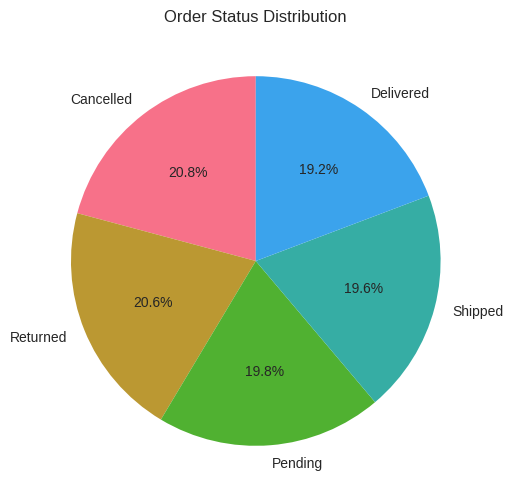

In [32]:
#pie chart for order status
plt.figure(figsize=(8, 6))
plt.pie(orders['OrderStatus'].value_counts(), labels=orders['OrderStatus'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.title('Order Status Distribution')
plt.show()

<Axes: xlabel='Product'>

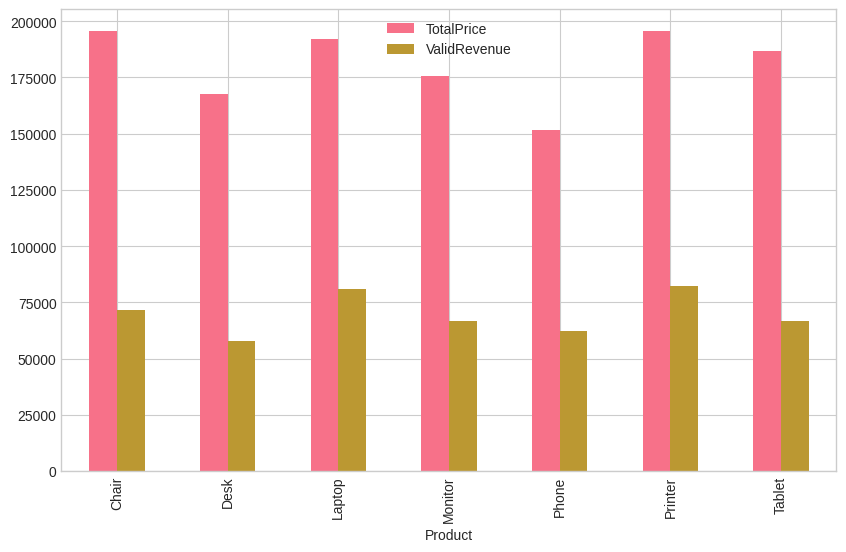

In [33]:
#compare Totalprice vs Validrevenue by product using plots
comparison = orders.groupby('Product')[['TotalPrice', 'ValidRevenue']].sum()
comparison.plot(kind='bar', figsize=(10, 6))

##What drives valid revenue?

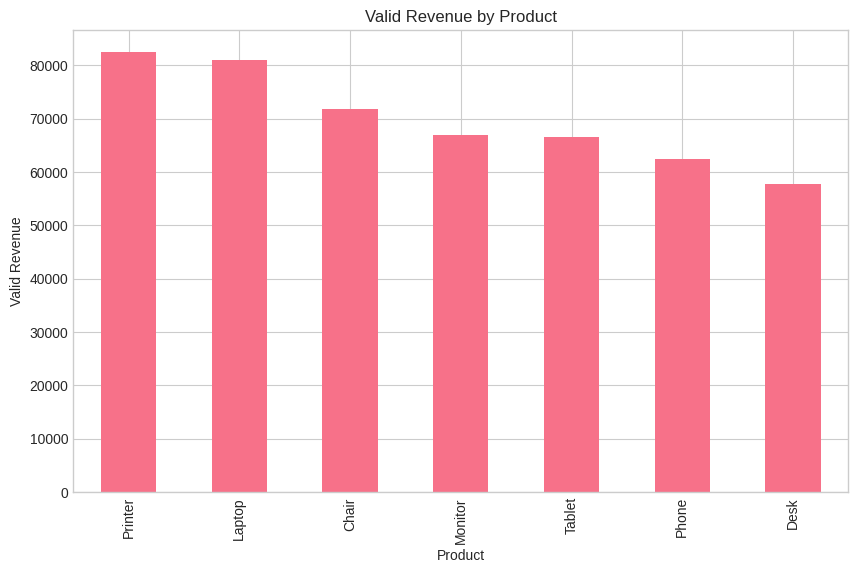

In [34]:
# valid revenue by product
valid_revenue_by_product = orders.groupby('Product')['ValidRevenue'].sum().sort_values(ascending=False)
valid_revenue_by_product.plot(kind='bar', figsize=(10, 6))
plt.title('Valid Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Valid Revenue')
plt.show()

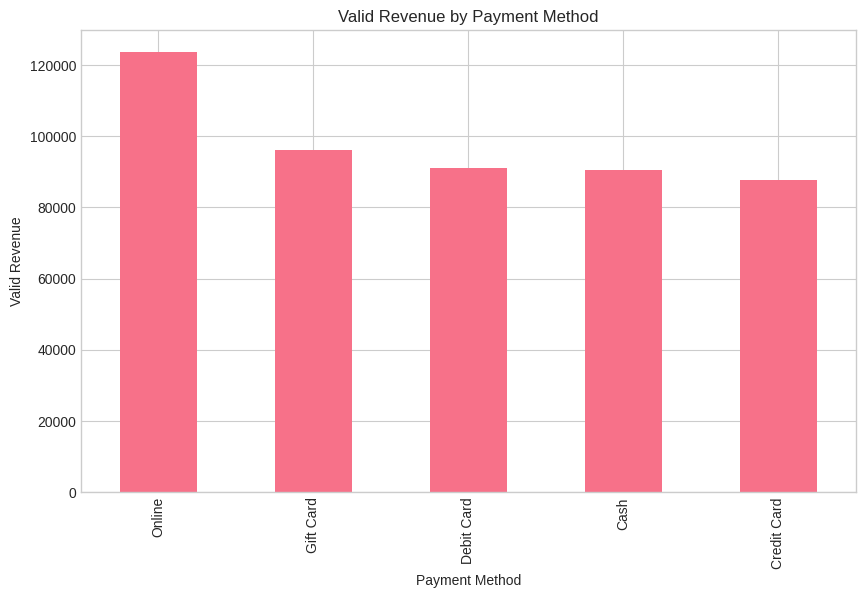

In [35]:
#valid revenue by payment method
valid_revenue_by_payment = orders.groupby('PaymentMethod')['ValidRevenue'].sum().sort_values(ascending=False)
valid_revenue_by_payment.plot(kind='bar', figsize=(10, 6))
plt.title('Valid Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Valid Revenue')
plt.show()

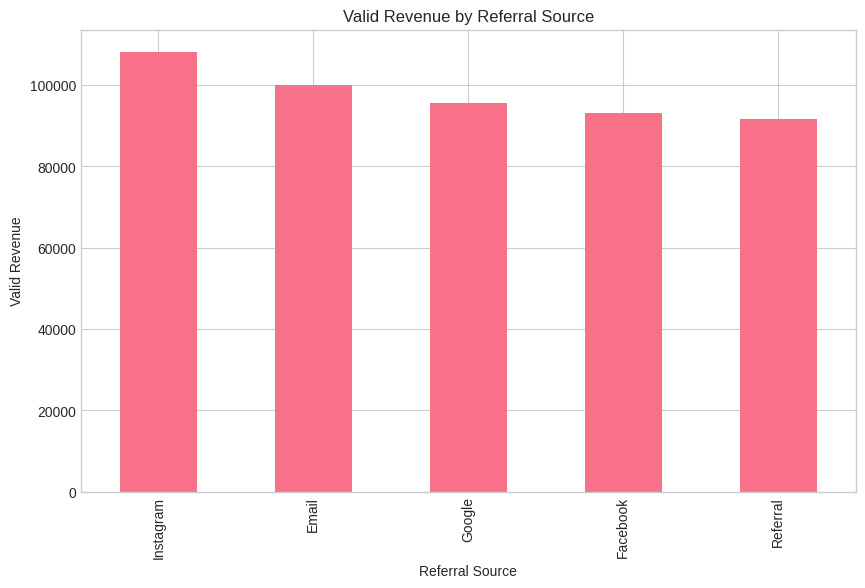

In [36]:
#valid revenue by referral source
valid_revenue_by_referral = orders.groupby('ReferralSource')['ValidRevenue'].sum().sort_values(ascending=False)
valid_revenue_by_referral.plot(kind='bar', figsize=(10, 6))
plt.title('Valid Revenue by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Valid Revenue')
plt.show()

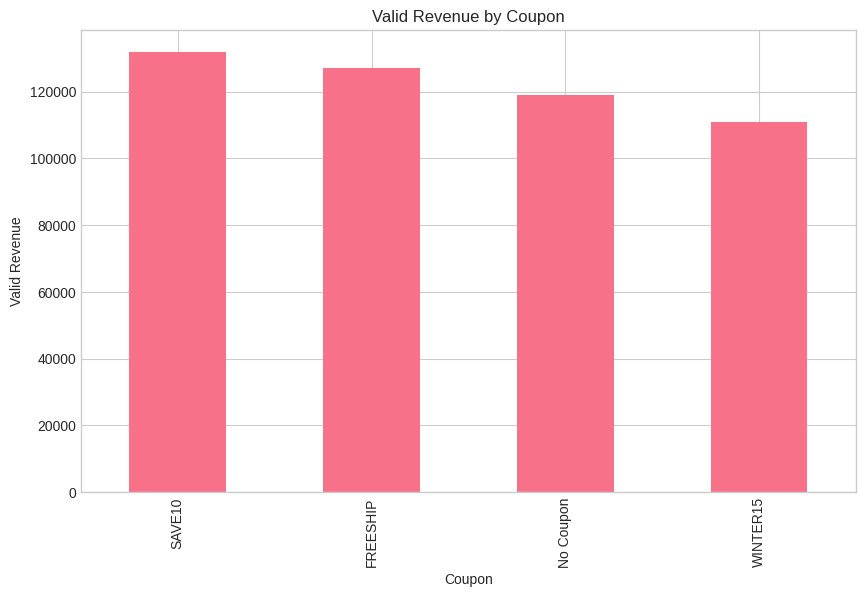

In [37]:
#valid revenue by coupon
valid_revenue_by_coupon = orders.groupby('CouponCode')['ValidRevenue'].sum().sort_values(ascending=False)
valid_revenue_by_coupon.plot(kind='bar', figsize=(10, 6))
plt.title('Valid Revenue by Coupon')
plt.xlabel('Coupon')
plt.ylabel('Valid Revenue')
plt.show()

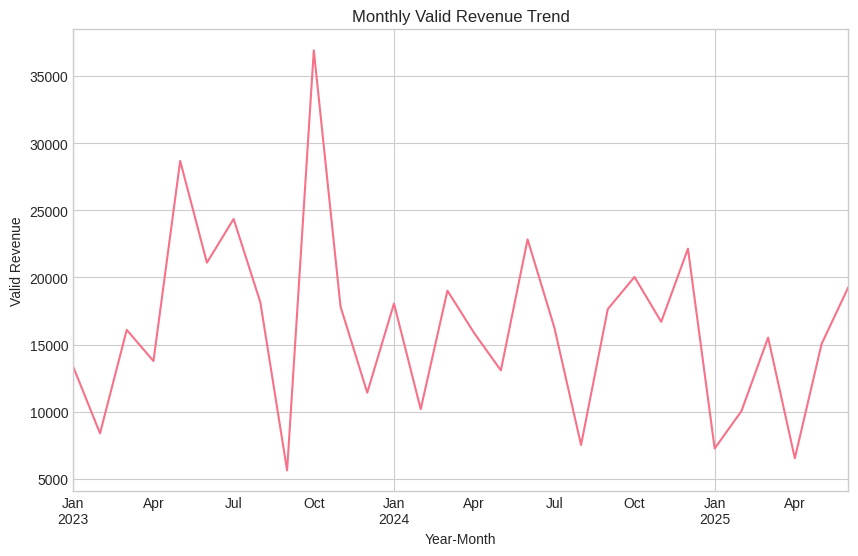

In [38]:
#monthly and yearly valid revenue trend
monthly_revenue = orders.groupby('Year-Month')['ValidRevenue'].sum()
monthly_revenue.plot(kind='line', figsize=(10, 6))
plt.title('Monthly Valid Revenue Trend')
plt.xlabel('Year-Month')
plt.ylabel('Valid Revenue')
plt.show()

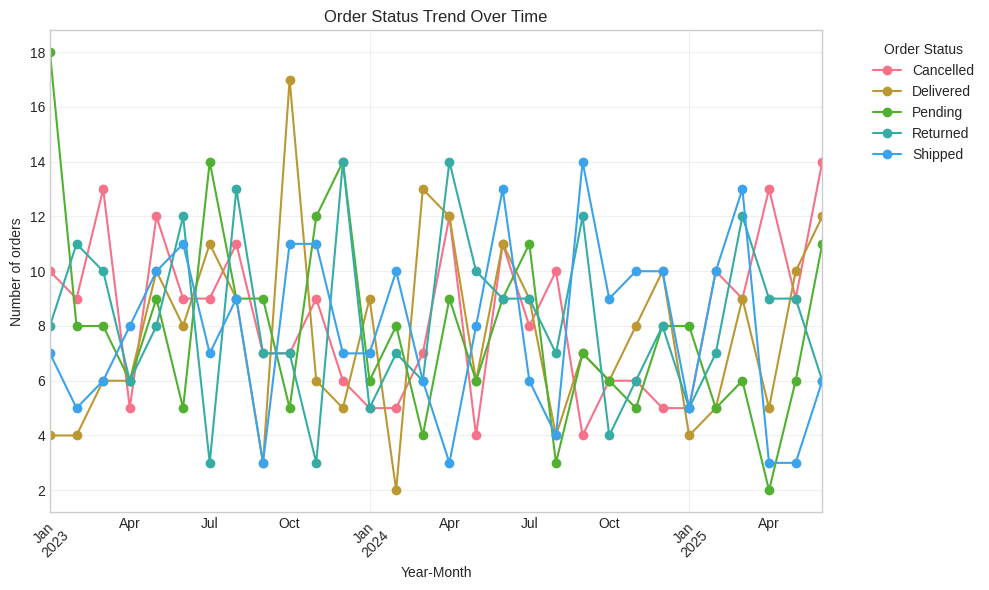

In [43]:
#order status over time
order_status_over_time = orders.groupby(['Year-Month', 'OrderStatus'])['OrderID'].count().unstack()
order_status_over_time.plot(kind='line', figsize=(10, 6), marker='o')
plt.title('Order Status Trend Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Number of orders')
plt.xticks(rotation=45)
plt.legend(title='Order Status', bbox_to_anchor= (1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Investigating why orders are being cancelled

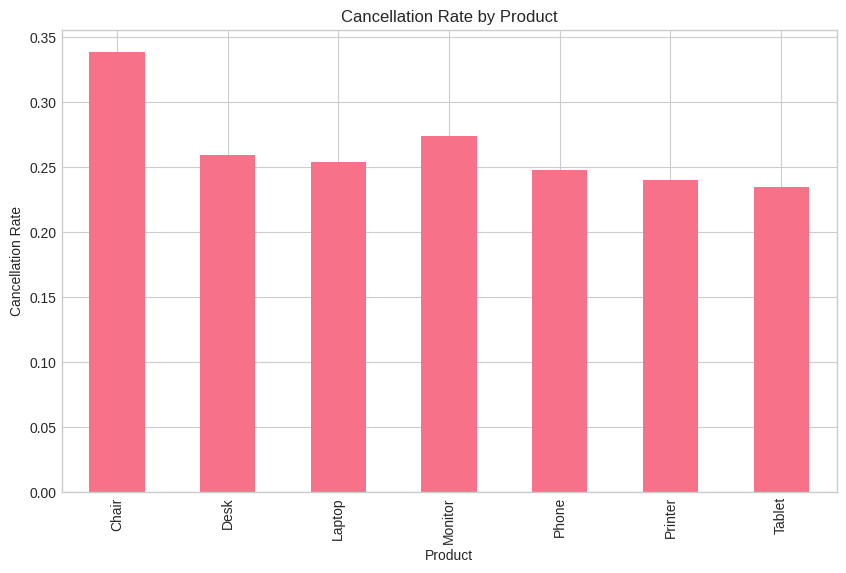

In [44]:
#cancellation rate by product
cancellation_rate_by_product = orders[orders['OrderStatus'] == 'Cancelled'].groupby('Product')['OrderID'].count() / orders[orders['OrderStatus'] != 'Cancelled'].groupby('Product')['OrderID'].count()
cancellation_rate_by_product.plot(kind='bar', figsize=(10, 6))
plt.title('Cancellation Rate by Product')
plt.xlabel('Product')
plt.ylabel('Cancellation Rate')
plt.show()

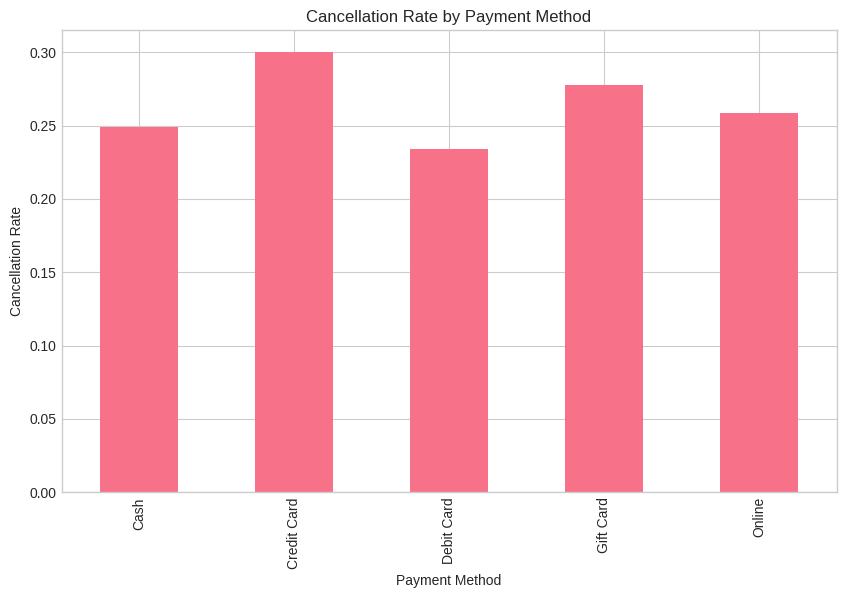

In [45]:
#cancellation rate by payment method
cancellation_rate_by_payment = orders[orders['OrderStatus'] == 'Cancelled'].groupby('PaymentMethod')['OrderID'].count() / orders[orders['OrderStatus'] != 'Cancelled'].groupby('PaymentMethod')['OrderID'].count()
cancellation_rate_by_payment.plot(kind='bar', figsize=(10, 6))
plt.title('Cancellation Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Cancellation Rate')
plt.show()

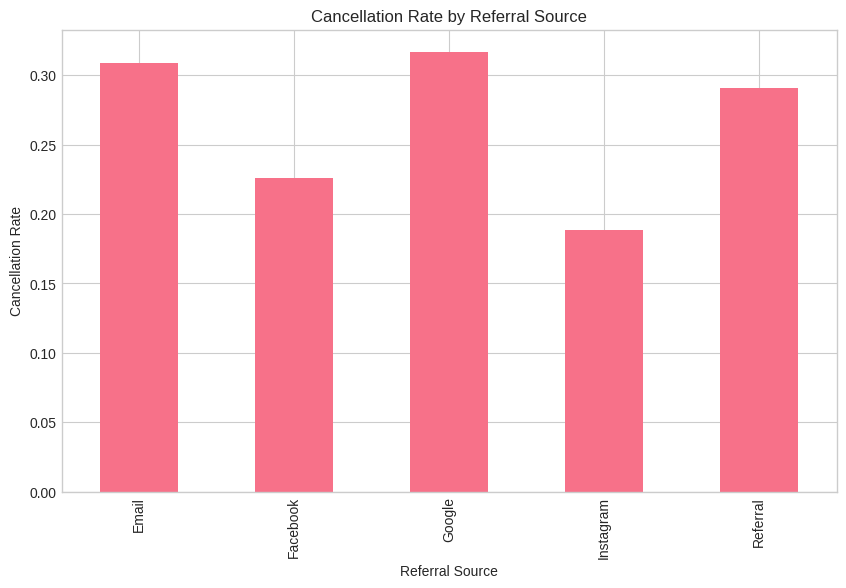

In [46]:
#cancellation by referral source
cancellation_rate_by_referral = orders[orders['OrderStatus'] == 'Cancelled'].groupby('ReferralSource')['OrderID'].count() / orders[orders['OrderStatus'] != 'Cancelled'].groupby('ReferralSource')['OrderID'].count()
cancellation_rate_by_referral.plot(kind='bar', figsize=(10, 6))
plt.title('Cancellation Rate by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Cancellation Rate')
plt.show()

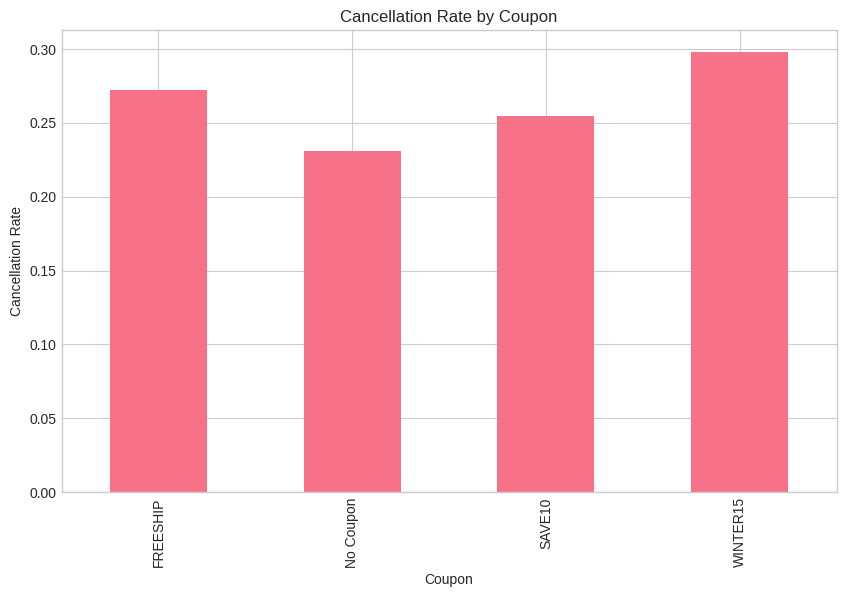

In [47]:
#cancellation rate by coupon
cancellation_rate_by_coupon = orders[orders['OrderStatus'] == 'Cancelled'].groupby('CouponCode')['OrderID'].count() / orders[orders['OrderStatus'] != 'Cancelled'].groupby('CouponCode')['OrderID'].count()
cancellation_rate_by_coupon.plot(kind='bar', figsize=(10, 6))
plt.title('Cancellation Rate by Coupon')
plt.xlabel('Coupon')
plt.ylabel('Cancellation Rate')
plt.show()

##Investigating why orders are pending

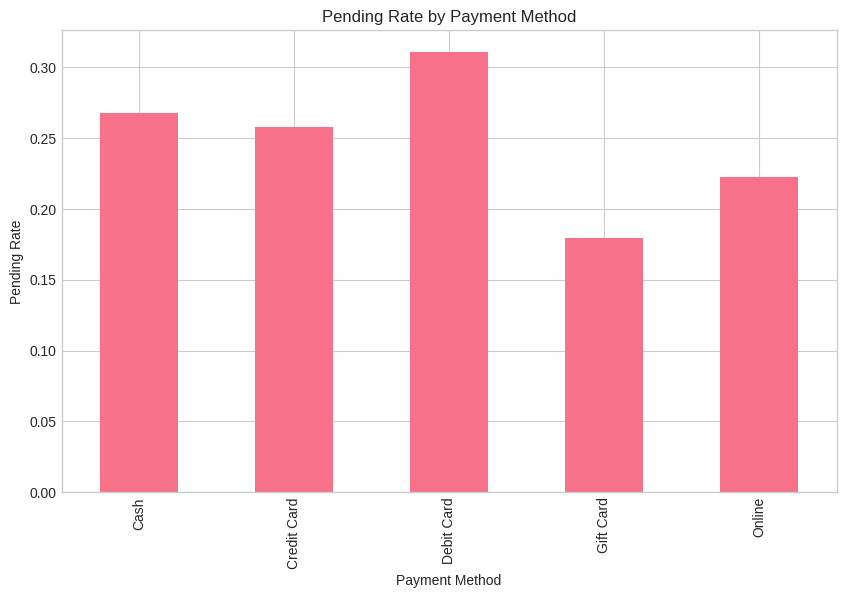

In [48]:
#pending rate by payment method
pending_rate_by_payment = orders[orders['OrderStatus'] == 'Pending'].groupby('PaymentMethod')['OrderID'].count() / orders[orders['OrderStatus'] != 'Pending'].groupby('PaymentMethod')['OrderID'].count()
pending_rate_by_payment.plot(kind='bar', figsize=(10, 6))
plt.title('Pending Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Pending Rate')
plt.show()

##Investigating Return rate

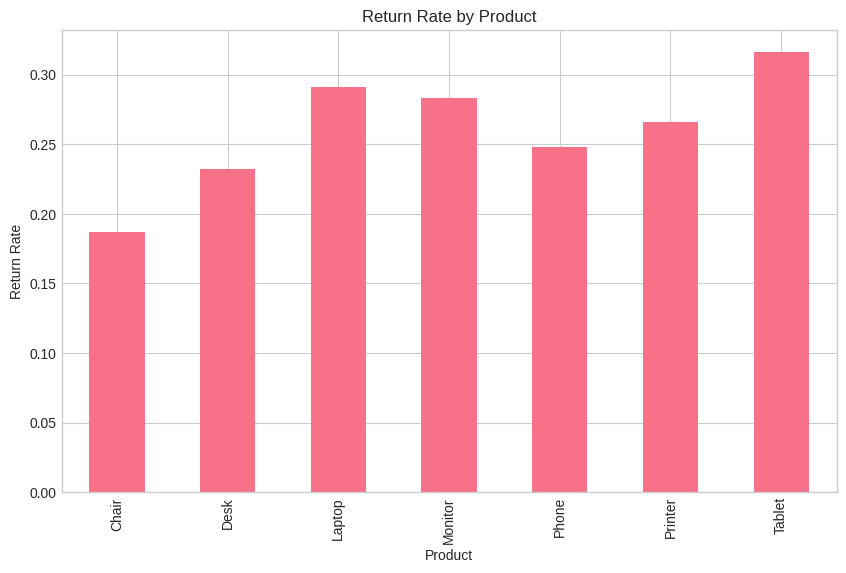

In [49]:
#return rate by product
return_rate_by_product = orders[orders['OrderStatus'] == 'Returned'].groupby('Product')['OrderID'].count() / orders[orders['OrderStatus'] != 'Returned'].groupby('Product')['OrderID'].count()
return_rate_by_product.plot(kind='bar', figsize=(10, 6))
plt.title('Return Rate by Product')
plt.xlabel('Product')
plt.ylabel('Return Rate')
plt.show()

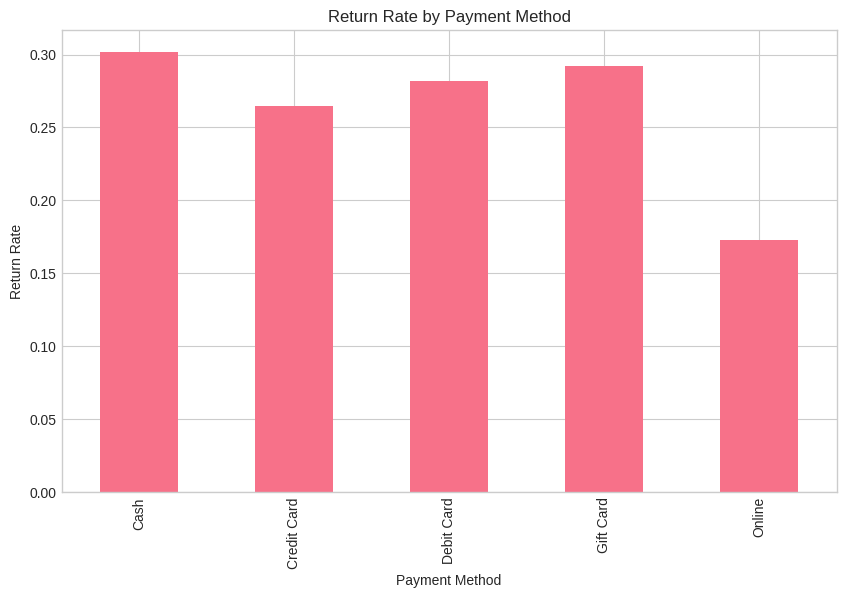

In [50]:
#return rate by payment method
return_rate_by_payment = orders[orders['OrderStatus'] == 'Returned'].groupby('PaymentMethod')['OrderID'].count() / orders[orders['OrderStatus'] != 'Returned'].groupby('PaymentMethod')['OrderID'].count()
return_rate_by_payment.plot(kind='bar', figsize=(10, 6))
plt.title('Return Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Return Rate')
plt.show()

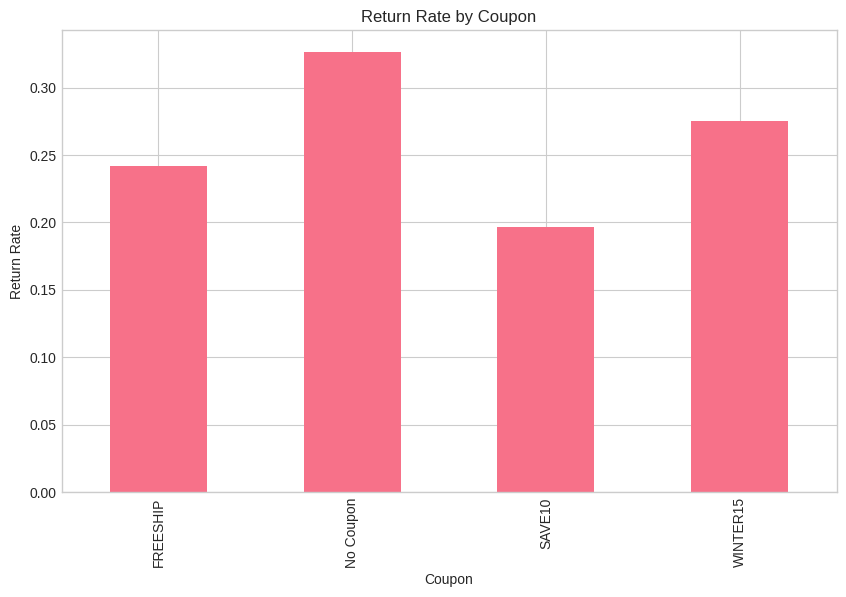

In [51]:
#return rate by coupon
return_rate_by_coupon = orders[orders['OrderStatus'] == 'Returned'].groupby('CouponCode')['OrderID'].count() / orders[orders['OrderStatus'] != 'Returned'].groupby('CouponCode')['OrderID'].count()
return_rate_by_coupon.plot(kind='bar', figsize=(10, 6))
plt.title('Return Rate by Coupon')
plt.xlabel('Coupon')
plt.ylabel('Return Rate')
plt.show()
#

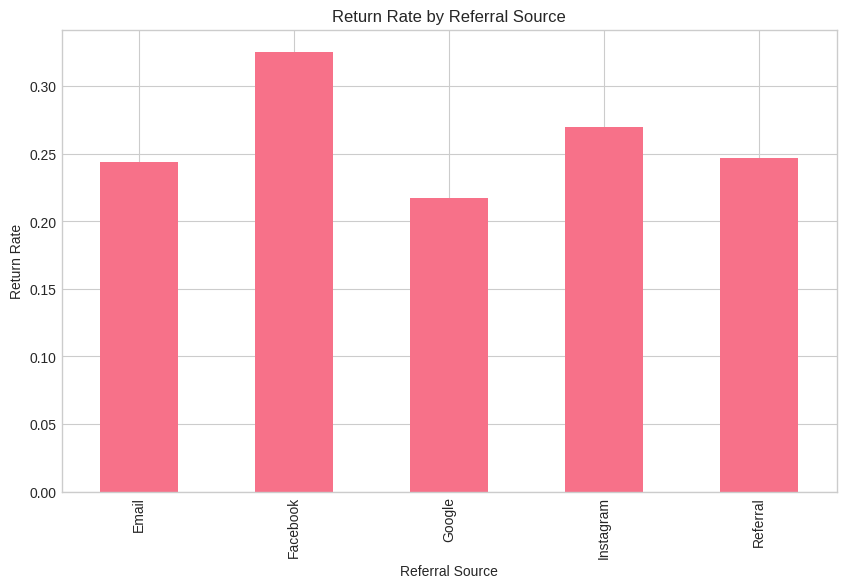

In [52]:
#return rate by referral source
return_rate_by_referral = orders[orders['OrderStatus'] == 'Returned'].groupby('ReferralSource')['OrderID'].count() / orders[orders['OrderStatus'] != 'Returned'].groupby('ReferralSource')['OrderID'].count()
return_rate_by_referral.plot(kind='bar', figsize=(10, 6))
plt.title('Return Rate by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Return Rate')
plt.show()

Order Failure Analysis:
Chair exhibits the highest cancellation rate, suggesting customers reconsider before shipment. Conversely, Tablet shows the highest return rate, indicating potential quality or expectation issues post-delivery.
WINTER15 coupon generates the most problematic orders (cancelled/returned), while orders without any coupon are most likely to complete successfully. This suggests aggressive discounts attract lower-commitment customers.
Debit Card payments have the highest pending and cancellation rates, possibly due to payment processing delays or insufficient funds. Gift Card users show the lowest pending rate.
Google referral traffic converts poorly compared to Instagram, suggesting Instagram audiences are more aligned with product offerings.